In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig, LoggingConfig, CheckpointConfig
from src.engine.runner import ExperimentRunner
from src.engine.optimizer import CMAESGameOptimizer

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- INPUTS ---
cmaes_id = "b2349d50"      # Replace with your target CMA-ES Session ID
output_dir = "../show_case_notebooks/outputs" # Path to the outputs folder
grid_size = 50             # Resolution of the 2D sweep grid
max_batch_size = 2000      # Safe GPU VRAM limits
# --------------

# Load the CMA-ES best weights
saved_data = CMAESGameOptimizer.load_results(cmaes_id, out_dir=output_dir)
best_payoffs = saved_data["payoffs"]
U1_base = best_payoffs[0].to(torch.float64)

# Print the loaded base matrix
print(f"Loaded CMA-ES U1 Base for Session {cmaes_id}:")
print(np.round(U1_base.numpy(), 4))

Loaded CMA-ES U1 Base for Session b2349d50:
[[ 0.5545 -0.176 ]
 [ 0.5437  0.6683]]


In [8]:
# 1. Parameterize the Dense Game Grid
X = torch.linspace(-1.0, 1.0, grid_size)
Y = torch.linspace(-1.0, 1.0, grid_size)
grid_X, grid_Y = torch.meshgrid(X, Y, indexing='ij')

total_games = grid_size * grid_size
X_flat = grid_X.flatten()
Y_flat = grid_Y.flatten()

# 2. Chunking to Prevent OOM
total_regret_list = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensure utility bounds don't crash validation if CMA-ES went slightly out of bounds
u_min, u_max = saved_data["config"]["game"]["utility_range"]
u_min = min(-1.0, float(U1_base.min()) - 0.1, u_min)
u_max = max(1.0, float(U1_base.max()) + 0.1, u_max)

print(f"Evaluating {total_games} games in chunks of {max_batch_size}...")

for i in tqdm(range(0, total_games, max_batch_size)):
    actual_chunk_size = min(max_batch_size, total_games - i)
    X_chunk = X_flat[i : i + actual_chunk_size]
    Y_chunk = Y_flat[i : i + actual_chunk_size]
    if actual_chunk_size < max_batch_size:
        pad_size = max_batch_size - actual_chunk_size
        X_chunk = torch.cat([X_chunk, X_chunk[:1].expand(pad_size)])
        Y_chunk = torch.cat([Y_chunk, Y_chunk[:1].expand(pad_size)])
    
    # Construct batched matrices for this chunk
    U1_batch = U1_base.unsqueeze(0).expand(max_batch_size, -1, -1)
    
    # We parameterize Player 2's matrix using the X, Y grid
    U2_batch = torch.zeros(max_batch_size, 2, 2, dtype=torch.float64)
    U2_batch[:, 0, 0] = X_chunk
    U2_batch[:, 0, 1] = Y_chunk
    U2_batch[:, 1, 0] = Y_chunk
    U2_batch[:, 1, 1] = X_chunk

    config = ExperimentConfig(
        game=GameConfig(
            num_players=2,
            action_sizes=[2, 2],
            generator="custom",
            utility_range=(float(u_min), float(u_max)),
            payoffs=[U1_batch.tolist(), U2_batch.tolist()]
        ),
        dynamic=DynamicConfig(
            algorithm="omwu",
            eta=0.05, 
            logit_penalty_threshold=15.0,
            logit_penalty_norm=2,
            logit_penalty_mode="centered"
        ),
        execution=ExecutionConfig(
            total_steps=200000,
            batch_size=max_batch_size,
            device=str(device),
            compile=True,
            quiet=True
        ),
        logging=LoggingConfig(log_level="ERROR"),
        checkpoint=CheckpointConfig(enabled=False)
    )

    runner = ExperimentRunner(config)
    with torch.no_grad():
        summary = runner.run()

    p1_regret = np.array(summary['final_cum_regrets'][0])[:actual_chunk_size]
    p2_regret = np.array(summary['final_cum_regrets'][1])[:actual_chunk_size]
    
    penalty = summary.get('logit_penalty', 0)
    if isinstance(penalty, torch.Tensor):
        penalty = penalty.cpu().numpy()[:actual_chunk_size]

    chunk_regret = p1_regret
    total_regret_list.append(chunk_regret)

# Reconstruct the 2D Landscape
total_regret_flat = np.concatenate(total_regret_list)
total_regret_2d = total_regret_flat.reshape((grid_size, grid_size))

Evaluating 2500 games in chunks of 2000...


  0%|          | 0/2 [00:00<?, ?it/s]

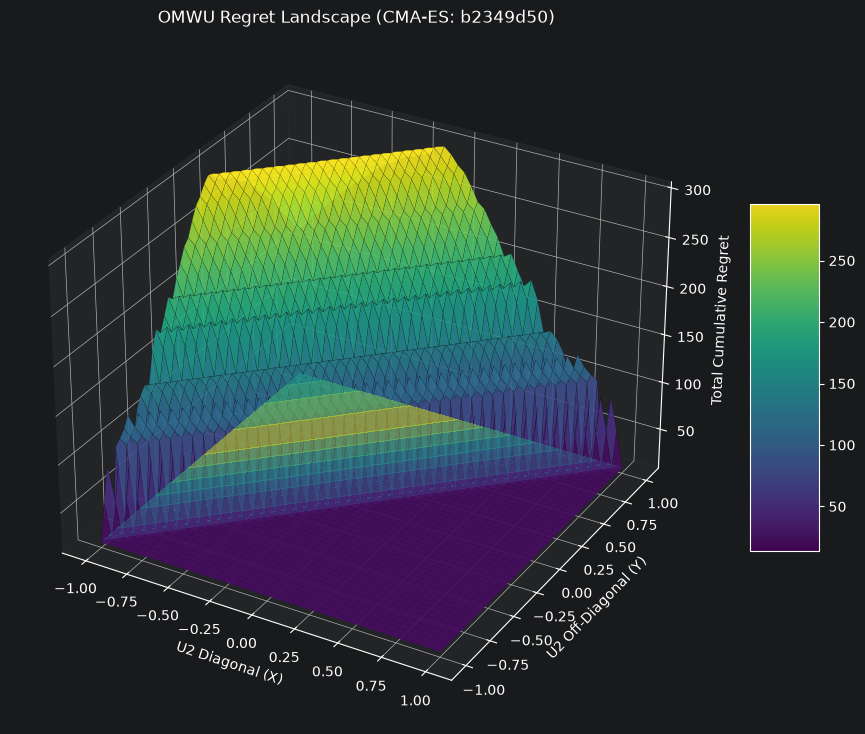

In [9]:
# 3. Plotting the 3D Surface
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(grid_X.numpy(), grid_Y.numpy(), total_regret_2d, cmap='viridis', alpha=0.9, edgecolor='k', linewidth=0.1)
ax.contourf(grid_X.numpy(), grid_Y.numpy(), total_regret_2d, zdir='z', offset=np.min(total_regret_2d), cmap='viridis', alpha=0.5)

ax.set_xlabel('U2 Diagonal (X)')
ax.set_ylabel('U2 Off-Diagonal (Y)')
ax.set_zlabel('Total Cumulative Regret')
ax.set_title(f'OMWU Regret Landscape (CMA-ES: {cmaes_id})')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()